# DEA Notebook 
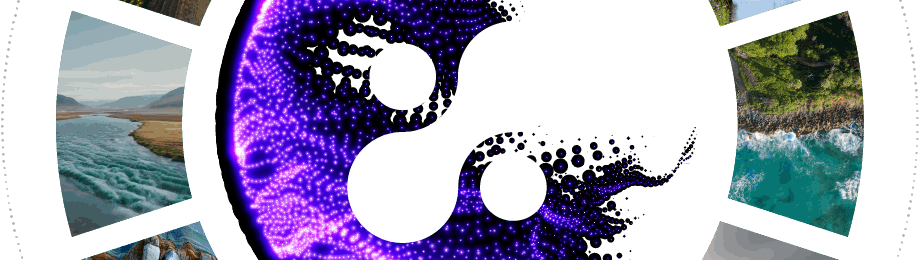 

### [DEA](https://dea.destine.eu/web) is a Content creation service and no-code platform for DestinE storytelling and data visualisation

# Dublin Bay Biosphere Marine Zones → KML for DEA

## Introduction

The **Dublin Bay Biosphere Reserve** was designated by UNESCO in 2015. Its marine area is
divided into three concentric zones following the standard UNESCO Biosphere Reserve framework:

| Zone | Role |
|---|---|
| **Core Zone** | Strictly protected — monitoring and low-impact research only |
| **Buffer Zone** | Surrounds the core — compatible research and low-impact recreation |
| **Transition Zone** | Outermost — sustainable development and community cooperation |

The data was downloaded from the **Irish Open Data Portal**:
[Dublin Bay Biosphere Marine Zones](https://data.gov.ie/dataset/dublin-bay-biosphere-marine-zones1).


### What we produce
| File | Content |
|---|---|
| `Dublin_Bay_Biosphere_Marine_Zones.kml` | 3 coloured polygon zones with description popup |

## 0. Download data from URL

In [ ]:
# ── Download input data ──────────────────────────────────────
import urllib.request
import zipfile
from pathlib import Path

INPUTS_DIR = Path("inputs")
INPUTS_DIR.mkdir(exist_ok=True)

downloads = {
    # Dublin Bay Biosphere Marine Zones (GeoJSON)
    "Dublin_Bay_Biosphere_Marine_Zones.geojson": (
        "https://msp-opendata-marineplan.hub.arcgis.com/api/download/v1/items/"
        "5a214b5a9f36488890304f71f474cdd6/geojson?layers=6"
    ),
    # Add more files here as needed:
    # "filename.zip": "https://...",
}

for filename, url in downloads.items():
    dest = INPUTS_DIR / filename
    if dest.exists():
        print(f"Already exists, skipping : {filename}")
        continue
    print(f"Downloading {filename}...")
    urllib.request.urlretrieve(url, dest)
    print(f"  Saved: {dest}  ({dest.stat().st_size/1024/1024:.1f} MB)")

print("Done.")

## 1. Setup

### Import necessary Python libraries

In [ ]:
import json
from pathlib import Path

## 2. Configuration [EDIT HERE YOUR SETTINGS]

All parameters that may need to be changed are defined here: 
- file paths, 
- zone colours,
-  popup descriptions.


### Notes
- To change zone colours, edit the `ZONE_STYLES` values in the Configuration cell
- To change opacity, adjust the first two hex digits (alpha)
- To edit popup text, update `ZONE_DESCRIPTIONS` in the Configuration cell

KML colours use **AABBGGRR** hex format (alpha, blue, green, red) — the reverse of the familiar RGBA order.
Alpha controls opacity: `78` ≈ 30%, `B4` ≈ 70%, `FF` = fully opaque.

In [ ]:
INPUT_GEOJSON = Path("inputs/Dublin_Bay_Biosphere_Marine_Zones.geojson")
OUTPUT_KML    = Path("outputs/Dublin_Bay_Biosphere_Marine_Zones.kml")

# Zone fill colours in KML AABBGGRR format
ZONE_STYLES = {
    "Core Zone Marine":         "78C8641E",   # blue,  ~47% opacity
    "Buffer Zone Marine":       "7878B43C",   # green, ~47% opacity
    "Transitional Zone Marine": "7828A0F0",   # amber, ~47% opacity
}
DEFAULT_FILL = "64B4B4B4"   # grey fallback

ZONE_DESCRIPTIONS = {
    "Core Zone Marine": (
        "The most strictly protected area of the Biosphere Reserve. "
        "Encompasses key marine habitats including SAC and SPA designations. "
        "Human activities limited to monitoring and low-impact research."
    ),
    "Buffer Zone Marine": (
        "Surrounds the Core Zone. Supports compatible research, education, "
        "and low-impact recreational activities such as guided tours and "
        "sustainable fishing."
    ),
    "Transitional Zone Marine": (
        "Outermost area where sustainable development is actively promoted. "
        "Includes shipping lanes, recreational areas, and zones of community "
        "cooperation under the Biosphere framework."
    ),
}

## 3. Load and Inspect the GeoJSON

In [ ]:
with open(INPUT_GEOJSON) as f:
    gj = json.load(f)

features = gj['features']
print(f"Features : {len(features)}")
print()
for feat in features:
    props = feat['properties']
    geom  = feat['geometry']
    print(f"Zone     : {props.get('zone')}")
    print(f"Geometry : {geom['type']}")
    print(f"Properties:")
    for k, v in props.items():
        print(f"  {k:20s}: {v}")
    print()

## 4. Generate KML

Each zone becomes a `<Placemark>` containing:
- `<name>` — shown in the DEA entity list
- `<description>` — HTML popup wrapped in `<![CDATA[...]]>` so HTML tags are not parsed as XML
- `<Style>` — fill colour via `<PolyStyle>`
- `<Polygon>` — coordinates as `lon,lat,alt` space-separated

A `MultiPolygon` produces one `<Placemark>` per polygon part.

In [ ]:
def build_description(props, zone):
    """Build HTML popup for DEA."""
    area_km2 = props.get('Shape__Area', 0) / 1_000_000
    updated  = props.get('Last_Updated', 'N/A')
    org      = props.get('Owning_Organisation', 'N/A')
    desc     = ZONE_DESCRIPTIONS.get(zone, 'Zone information not available.')

    return (
        "<div style='min-width:300px;padding:8px;background:#1a1a2e;color:#e0e0e0;border-radius:6px;'>"
        f"<b style='font-size:15px;color:#ffffff;'>{zone}</b><br><br>"
        f"<p style='font-size:13px;color:#b0b0b0;'>{desc}</p>"
        "<table style='font-family:sans-serif;font-size:13px;width:100%;border-collapse:collapse;'>"
        f"<tr><td style='color:#888;padding:3px 8px 3px 0;'>Area</td><td style='color:#e0e0e0;'>{area_km2:.1f} km²</td></tr>"
        f"<tr><td style='color:#888;padding:3px 8px 3px 0;'>Last updated</td><td style='color:#e0e0e0;'>{updated}</td></tr>"
        f"<tr><td style='color:#888;padding:3px 8px 3px 0;'>Organisation</td><td style='color:#e0e0e0;'>{org}</td></tr>"
        "</table></div>"
    )


def ring_to_kml(ring):
    """Convert a coordinate ring to KML coordinates string."""
    return ' '.join(f"{lon},{lat},0" for lon, lat in ring)


placemarks = []
for feat in features:
    props = feat['properties']
    zone  = props.get('zone', '')
    fill  = ZONE_STYLES.get(zone, DEFAULT_FILL)
    geom  = feat['geometry']
    desc  = build_description(props, zone)

    polys = [geom['coordinates']] if geom['type'] == 'Polygon' else geom['coordinates']

    for poly in polys:
        outer = ring_to_kml(poly[0])
        placemarks.append(f"""
  <Placemark>
    <name>{zone}</name>
    <description><![CDATA[{desc}]]></description>
    <Style>
      <PolyStyle>
        <color>{fill}</color>
      </PolyStyle>
    </Style>
    <Polygon>
      <altitudeMode>clampToGround</altitudeMode>
      <outerBoundaryIs>
        <LinearRing><coordinates>{outer}</coordinates></LinearRing>
      </outerBoundaryIs>
    </Polygon>
  </Placemark>""")

kml = f"""<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2">
<Document>
  <name>Dublin Bay Biosphere Marine Zones</name>
{''.join(placemarks)}
</Document>
</kml>"""

OUTPUT_KML.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_KML.write_text(kml, encoding='utf-8')

size_kb = OUTPUT_KML.stat().st_size / 1024
print(f"Saved : {OUTPUT_KML.name}")
print(f"Size  : {size_kb:.1f} KB  ({len(placemarks)} placemarks)")

## 5. Upload the KML file to DEA and use it in a story

### You can now upload the generated KML file to the [DEA Story Editor](https://dea.destine.eu/stories/editor).

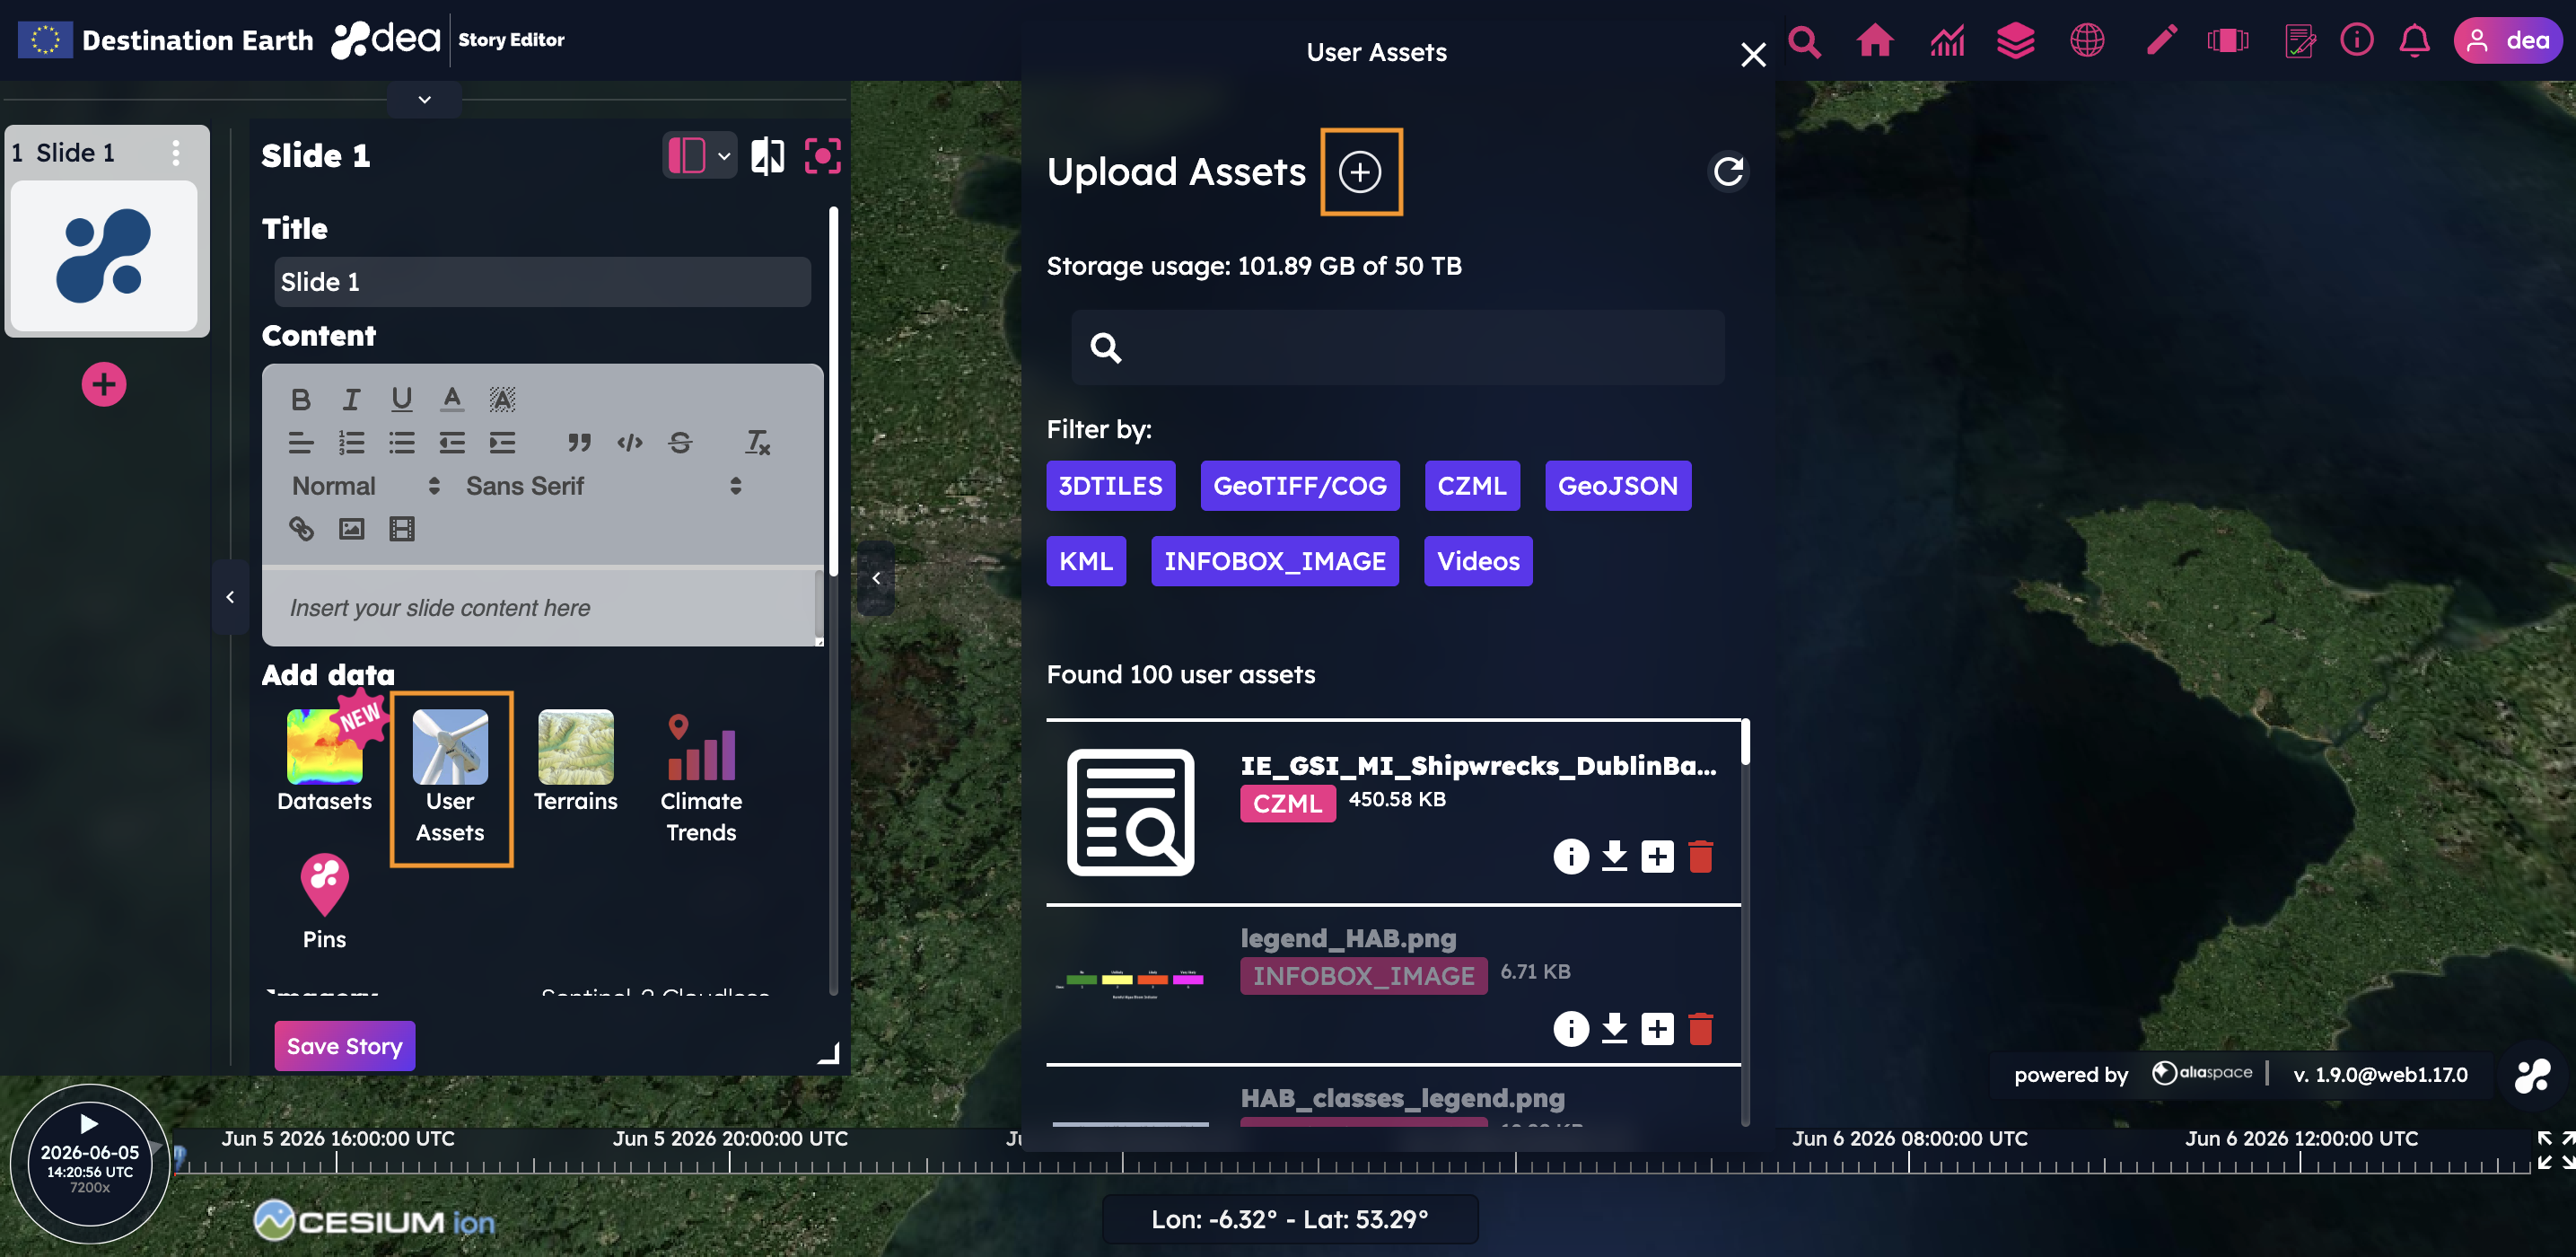

### The asset can be included in your stories.

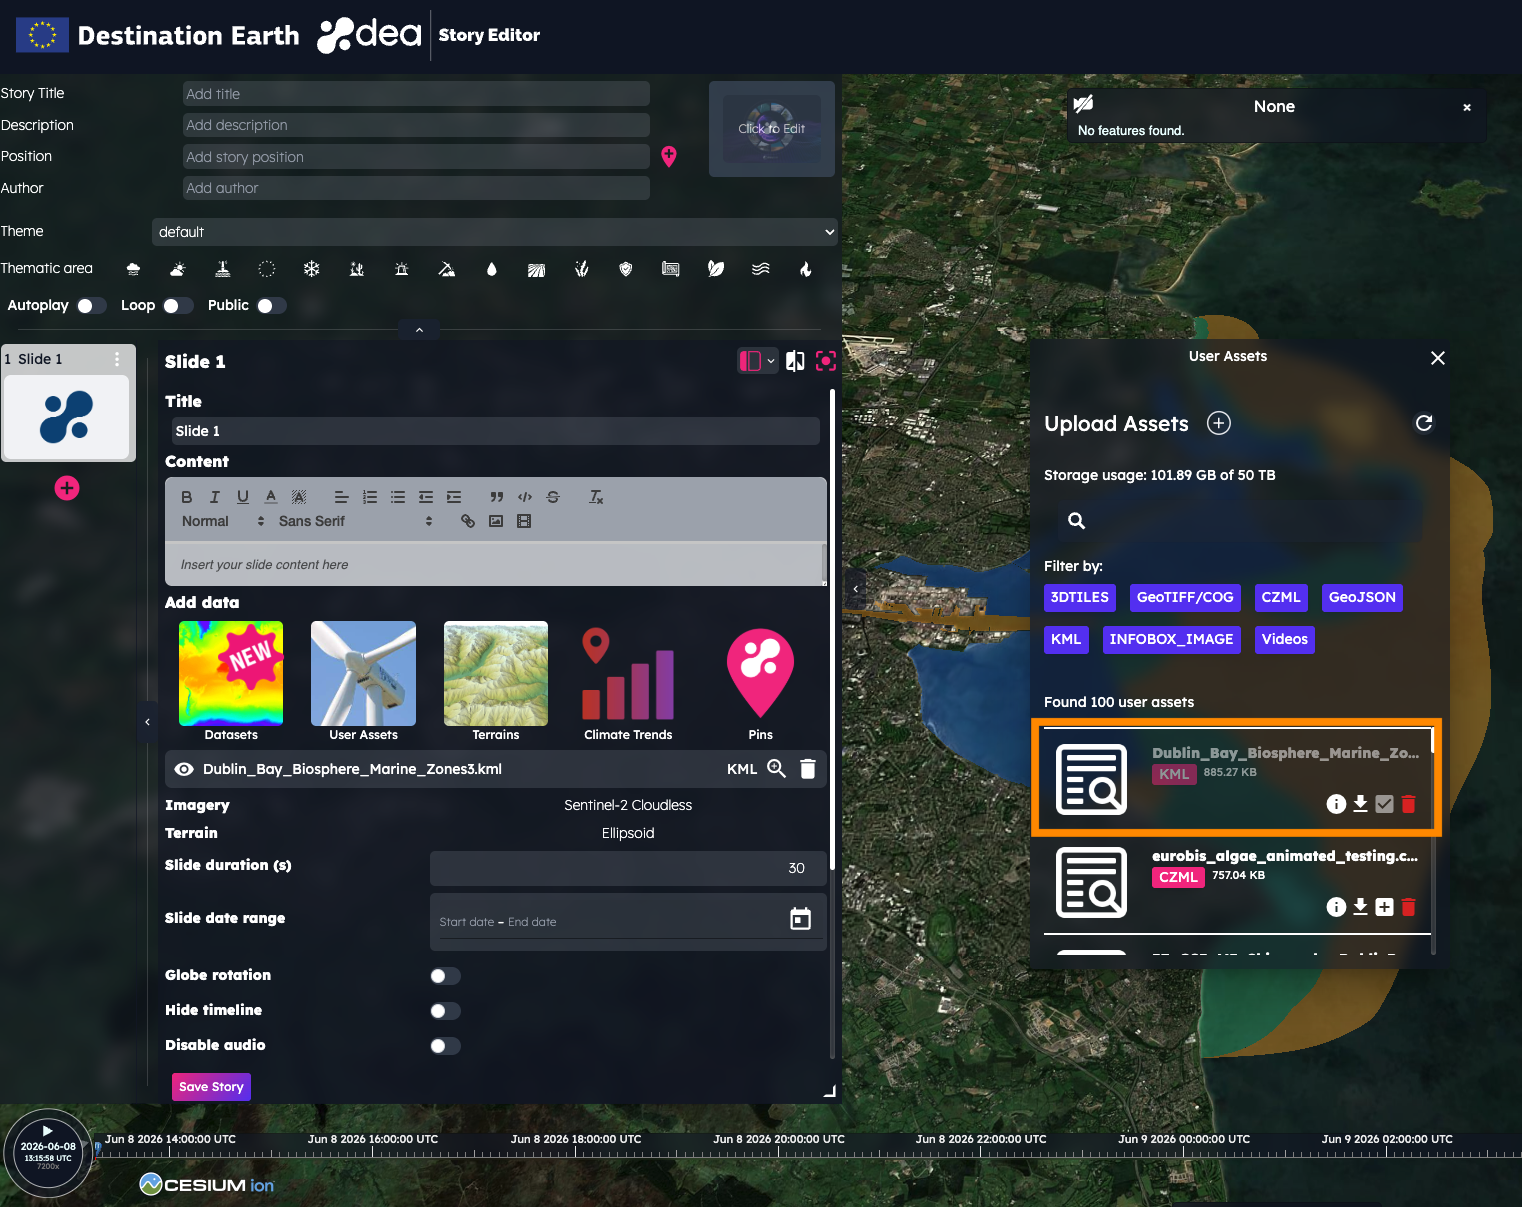

### Timeline settings

As the layer is static version of the file, simply hide the timeline.

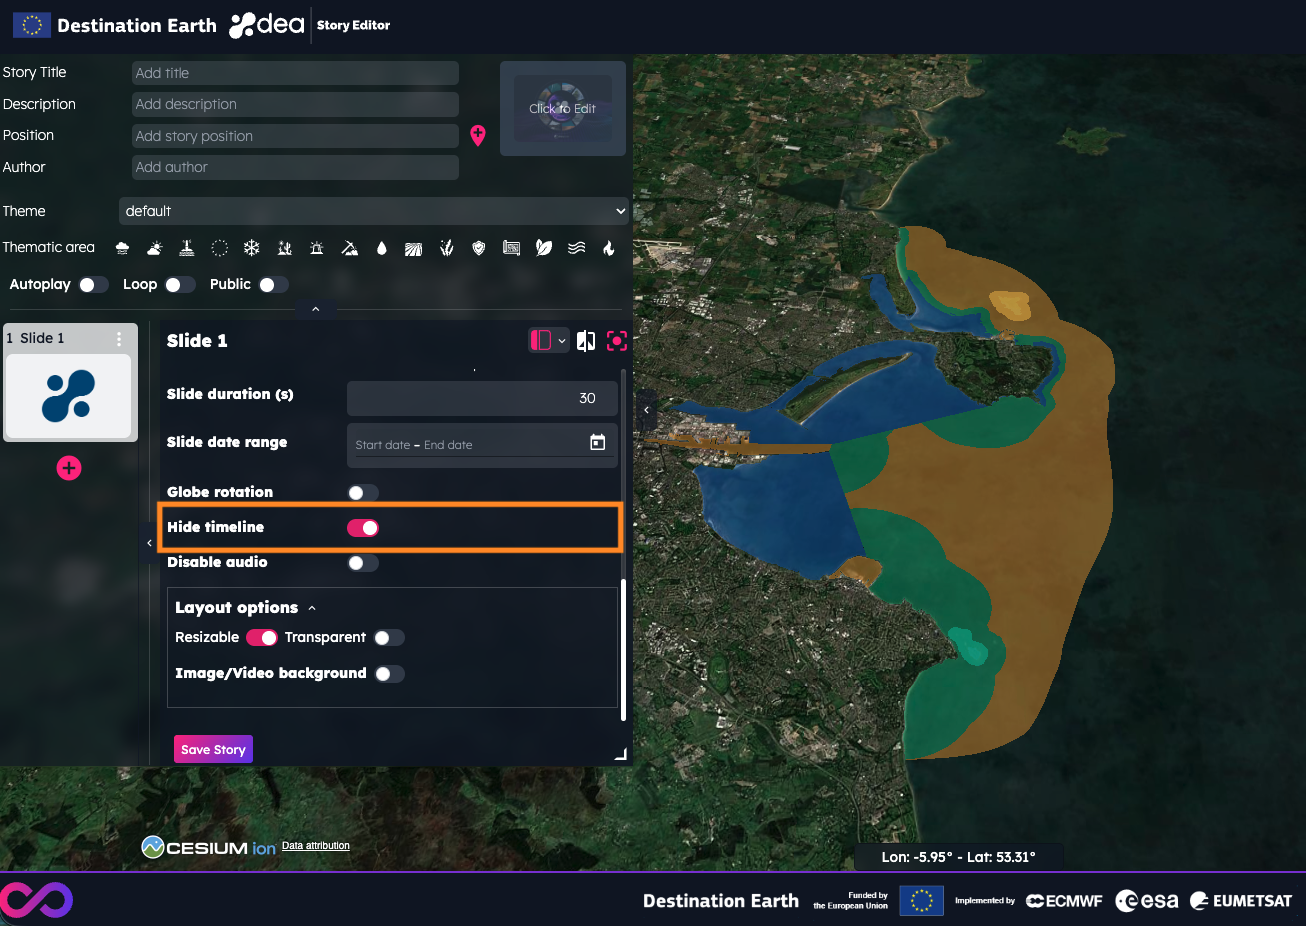


<center style="font-size: 40pt;"><b>Hope you love it!</b></center>

<div>
    <center>
        <img src="../figures/final_res_kml.png" width="800"/>
    </center>
</div>

<center style="font-size: 30pt;">
    <a href="mailto:dea-support@alia-space.com">dea-support@alia-space.com</a>
</center>
<br>